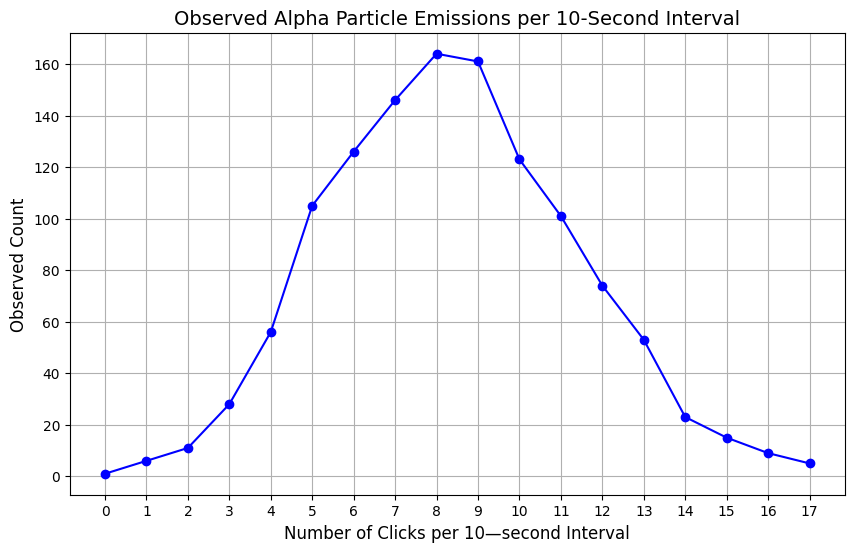

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Data
ClicksPerTenSeconds=np.arange(18) # Number Of counts per lø—second interval
ObservedCounts = [ 1, 6, 11, 28, 56, 105, 126, 146, 164, 161, 123, 101, 74, 53, 23, 15, 9, 5]

# Plotting the observed data
plt.figure(figsize=(10,6))
plt.plot(ClicksPerTenSeconds, ObservedCounts,  marker='o' , linestyle='-' ,color='blue')
# Adding labels and titte

plt.title( 'Observed Alpha Particle Emissions per 10-Second Interval', fontsize=14)
plt.xlabel( 'Number of Clicks per 10—second Interval',fontsize=12)
plt.ylabel( 'Observed Count', fontsize=12)
plt.grid(True)
# Set x—axis to display integer tick marks only
plt.xticks(ticks=np.arange(0,max(ClicksPerTenSeconds)+1,1))
# Show the plot
plt.show()

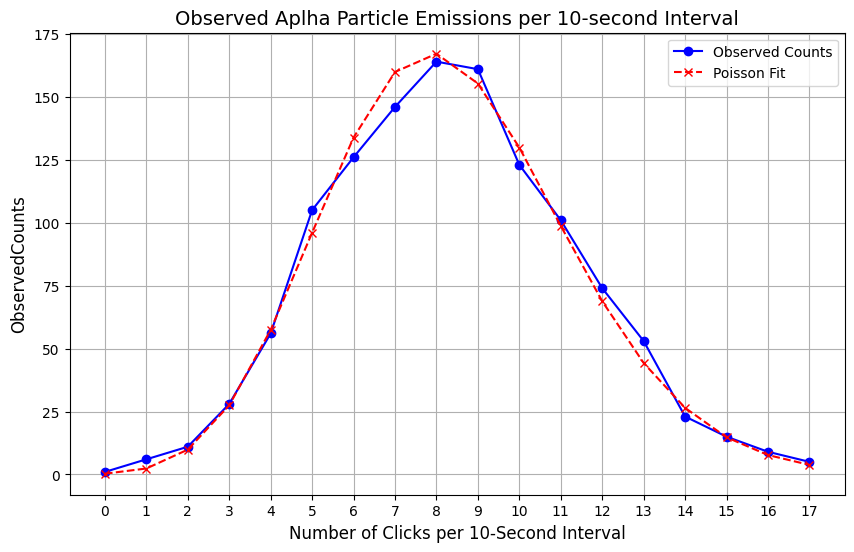

In [4]:
from scipy.stats import poisson

sample_mean=np.average(ClicksPerTenSeconds,weights=ObservedCounts)

poisson_dist=poisson.pmf(ClicksPerTenSeconds,mu=sample_mean)*np.sum(ObservedCounts)

plt.figure(figsize=(10,6))
plt.plot(ClicksPerTenSeconds,ObservedCounts,marker='o',linestyle='-',color='blue',label='Observed Counts')

plt.plot(ClicksPerTenSeconds,poisson_dist,marker='x',linestyle='--',color='red',label=f'Poisson Fit ')

plt.title('Observed Aplha Particle Emissions per 10-second Interval',fontsize=14)
plt.xlabel('Number of Clicks per 10-Second Interval',fontsize=12)
plt.ylabel('ObservedCounts',fontsize=12)
plt.grid(True)
plt.legend()

plt.xticks(ticks=np.arange(0,max(ClicksPerTenSeconds)+1,1))

plt.show()



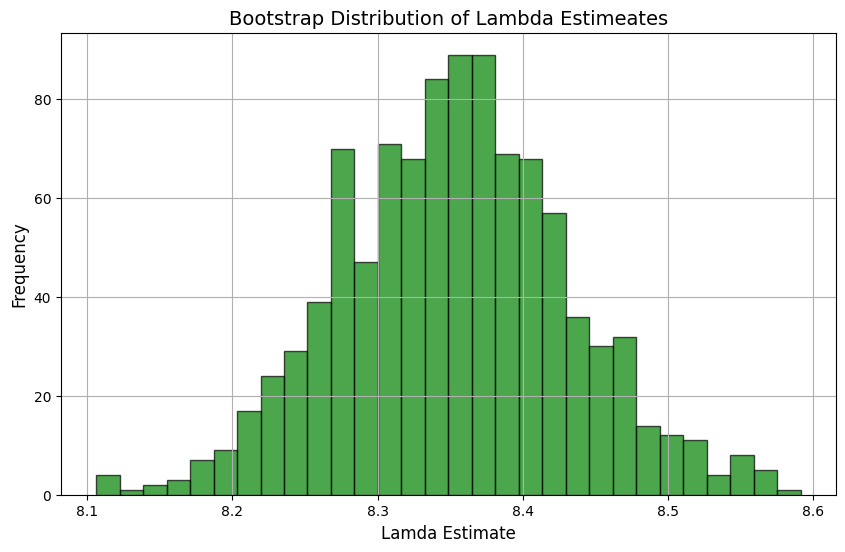

The mean of the bootsrap lambda is 8.3524
The standard deviation of the bootstrap lamda is 0.0788


In [5]:
import numpy as np
import matplotlib. pyplot as plt
from scipy.stats import poisson
# Data
n = np.arange(18) # Number of counts per 10—second interval
Observed= [1, 6, 11, 28, 56, 105, 126, 146, 164, 161, 123, 101, 74,53,23,15,9,5]

# Calculate the sample mean (initial estimate of lambda)
sample_mean = np.average(n,weights=Observed)
# Number of bootstrap samples
num_bootstrap = 1000
bootstrap_lambdas = []
# Bootstrap procedure
for _ in range(num_bootstrap):
    synthetic_data=np.random.poisson(lam=sample_mean,size=np.sum(Observed))

    synthetic_hist,_=np.histogram(synthetic_data,bins=np.arange(19))

    new_lambda=np.average(n,weights=synthetic_hist)

    bootstrap_lambdas.append(new_lambda)

plt.figure(figsize=(10,6))
plt.hist(bootstrap_lambdas,bins=30,color='green',edgecolor='black',alpha=0.7)
plt.title('Bootstrap Distribution of Lambda Estimeates',fontsize=14)
plt.xlabel('Lamda Estimate',fontsize=12)
plt.ylabel('Frequency',fontsize=12)
plt.grid(True)

plt.show()

bootstrap_mean=np.mean(bootstrap_lambdas)
bootsrap_std=np.std(bootstrap_lambdas)
print(f"The mean of the bootsrap lambda is {bootstrap_mean:.4f}")
print(f"The standard deviation of the bootstrap lamda is {bootsrap_std:.4f}")

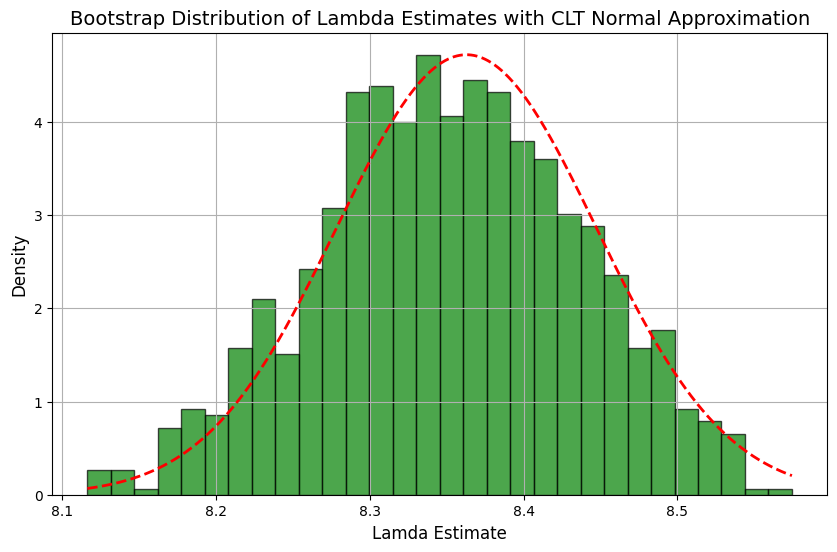

In [ ]:
import numpy as np
import matplotlib. pyplot as plt
from scipy.stats import poisson,norm
# Data
n = np.arange(18) # Number of counts per 10—second interval
Observed= [1, 6, 11, 28, 56, 105, 126, 146, 164, 161, 123, 101, 74,53,23,15,9,5]

# Calculate the sample mean (initial estimate of lambda)
sample_mean = np.average(n,weights=Observed)
# Number of bootstrap samples
num_bootstrap = 1000
bootstrap_lambdas = []
# Bootstrap procedure
for _ in range(num_bootstrap):
    synthetic_data=np.random.poisson(lam=sample_mean,size=np.sum(Observed))

    synthetic_hist,_=np.histogram(synthetic_data,bins=np.arange(19))

    new_lambda=np.average(n,weights=synthetic_hist)

    bootstrap_lambdas.append(new_lambda)

observed_std=np.sqrt(np.average((n-sample_mean)**2,weights=Observed))

clt_std=observed_std/np.sqrt(sum(Observed))


plt.figure(figsize=(10,6))
plt.hist(bootstrap_lambdas,bins=30,color='green',edgecolor='black',alpha=0.7,density=True)

x=np.linspace(min(bootstrap_lambdas),max(bootstrap_lambdas),1000)
normal_approximation=norm.pdf(x,loc=sample_mean,scale=clt_std)
plt.plot(x,normal_approximation,'r--',lw=2,label=f'Normal Approximation (CLT)\n(mean={sample_mean})')

plt.title('Bootstrap Distribution of Lambda Estimates with CLT Normal Approximation',fontsize=14)
plt.xlabel('Lamda Estimate',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.grid(True)

plt.show()